# Module adaptatif — Synthèse MNIST (0-9)

Recherche sur un **module adaptatif** type MoE appliqué à MNIST (0-9). Ce notebook de synthèse reproduit de façon compacte le pipeline complet : entraînement progressif, analyse des bridges de couches, **compression autonome**, et **comparaison avec un MLP dense**. Les détails par étape sont dans `README.md`.

## Étapes
1. **Entraînement progressif** : un expert par chiffre, gelés au fur et à mesure.
2. **Bridges** : détection des couches fc1 redondantes entre experts.
3. **Compression autonome** : fusion des couches partagées + validation par seuil de perte.
4. **Comparaison MLP** : MoE compressé vs MLP dense entraîné sur les 10 chiffres d'un coup.

> Le LLM local (optionnel) peut générer du code, mais n'est pas requis pour cette synthèse.

## 0. Imports

In [1]:
# Synthèse : module adaptatif MoE sur MNIST (0-9)
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from recherche_agi import (load_mnist, filter_by_digits, train_tiny_moe,
    evaluate, freeze_experts, unfreeze_experts, train_router,
    train_expert_on_dataset, server_healthy)

## 1. Données : MNIST (0-9)

In [2]:
train_set, test_set = load_mnist()
def subset(digits): return filter_by_digits(train_set, test_set, digits=digits, val_fraction=0.1)
sets_all = {d: subset(list(range(d + 1))) for d in range(10)}
print("Train :", len(train_set), "| Test :", len(test_set))

Train : 60000 | Test : 10000


## 2. Modèle MoE + entraînement progressif (un expert par chiffre)

In [3]:
# --- Le modèle MoE (un expert par chiffre) ---
class TinyExpert(nn.Module):
    def __init__(self, d_in=784, hidden=16, d_out=1, classes=(0,), seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.d_in = d_in; self.hidden = hidden; self.d_out = d_out
        self.classes = tuple(classes)
        self.fc1 = nn.Linear(d_in, hidden); self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, d_out)
    def forward(self, x):
        return self.fc2(self.act(self.fc1(x.flatten(1))))

class TinyMoE(nn.Module):
    def __init__(self, d_in=784, hidden=16, temperature=1.0, seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.d_in = d_in; self.hidden = hidden; self.temperature = temperature
        self.router = nn.Linear(d_in, 1)
        self.experts = nn.ModuleList(); self.num_classes = 0
        self.forced_expert = None; self.last_routing = None

    def add_expert(self, classes, hidden=None, seed=0):
        idx = len(self.experts)
        self.experts.append(TinyExpert(self.d_in, hidden or self.hidden, len(classes),
                                       classes, idx if seed is None else seed))
        old = self.router; nr = nn.Linear(self.d_in, idx + 1)
        with torch.no_grad():
            nr.weight.data[:idx] = old.weight.data; nr.bias.data[:idx] = old.bias.data
            nr.weight.data[idx] = 0.0; nr.bias.data[idx] = 0.0
        self.router = nr; self.num_classes += len(classes)
        return idx

    def routing_weights(self, x):
        return torch.softmax(self.router(x.flatten(1)) / self.temperature, dim=-1)
    def expert_for_class(self, cls):
        for i, exp in enumerate(self.experts):
            if cls in exp.classes:
                return i
        raise ValueError(f"Aucun expert ne gère la classe {cls}")


    def forward(self, x):
        w = self.routing_weights(x)
        if self.forced_expert is not None:
            w = torch.zeros_like(w); w[:, self.forced_expert] = 1.0
        self.last_routing = w.detach()
        out = torch.zeros(len(x), self.num_classes)
        for i, exp in enumerate(self.experts):
            lg = exp(x); contrib = torch.zeros(len(x), self.num_classes)
            for k, cls in enumerate(exp.classes): contrib[:, cls] = lg[:, k]
            out = out + w[:, i].unsqueeze(1) * contrib
        return out

    def n_params(self):
        return sum(p.numel() for p in self.parameters())

In [4]:
torch.manual_seed(0)
model = TinyMoE(hidden=16)
seen = []
for d in range(10):
    idx = model.add_expert((d,))
    freeze_experts(model, seen)
    data = sets_all[d]
    train_tiny_moe(model, {"train": data['train'], "val": data['val']},
        epochs=8, batch_size=256, lr=1e-3, every_n=100, verbose=False)
    seen.append(idx)
freeze_experts(model, seen)
train_router(model, {"train": sets_all[9]['train'], "val": sets_all[9]['val']},
    epochs=30, batch_size=256, lr=1e-3, every_n=100, verbose=False)
acc_moe_init = evaluate(model, sets_all[9]['test'][0], sets_all[9]['test'][1])
print(f"MoE 10 experts (non compressé) : {model.n_params()} params | acc {acc_moe_init:.4f}")

MoE 10 experts (non compressé) : 133620 params | acc 0.8421


## 3. Bridges : similarité de couche fc1 entre experts

In [5]:
# --- Analyse de similarité de couche & bridges ---
def layer_activation_similarity(model, digits_data):
    n_exp = len(model.experts)
    Xall = torch.cat(list(digits_data.values()))
    model.eval()
    with torch.no_grad():
        acts = [e.shared.act(e.shared.fc1(Xall.flatten(1))).numpy() if hasattr(e, 'shared')
                else e.act(e.fc1(Xall.flatten(1))).numpy() for e in model.experts]
    acts_norm = [A / (np.linalg.norm(A, axis=0, keepdims=True) + 1e-8) for A in acts]
    bestcos = np.zeros((n_exp, n_exp))
    for i in range(n_exp):
        for j in range(n_exp):
            if i == j: bestcos[i, j] = 1.0; continue
            bestcos[i, j] = (acts_norm[i].T @ acts_norm[j]).max()
    return bestcos

def find_layer_bridges(model, a, b, digits_data, threshold=0.85):
    Xall = torch.cat(list(digits_data.values()))
    model.eval()
    with torch.no_grad():
        if hasattr(model.experts[a], 'shared'):
            A = model.experts[a].shared.act(model.experts[a].shared.fc1(Xall.flatten(1))).numpy()
            B = model.experts[b].shared.act(model.experts[b].shared.fc1(Xall.flatten(1))).numpy()
        else:
            A = model.experts[a].act(model.experts[a].fc1(Xall.flatten(1))).numpy()
            B = model.experts[b].act(model.experts[b].fc1(Xall.flatten(1))).numpy()
    A = A / (np.linalg.norm(A, axis=0, keepdims=True) + 1e-8)
    B = B / (np.linalg.norm(B, axis=0, keepdims=True) + 1e-8)
    C = A.T @ B
    pairs = [(i, np.argmax(C[i]), float(C[i].max())) for i in range(C.shape[0]) if C[i].max() >= threshold]
    return pairs

def plot_heatmap(mat, title, labels, cmap='coolwarm', vmin=0, vmax=1):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha='center', va='center', fontsize=7, color='white')
    plt.colorbar(im, ax=ax); ax.set_title(title)
    plt.tight_layout(); plt.show()

def discover_pairs(model, digits_data, n_bridges_min=4, threshold=0.85):
    n_exp = len(model.experts)
    pairs = []
    for a in range(n_exp):
        for b in range(a + 1, n_exp):
            nb = len(find_layer_bridges(model, a, b, digits_data, threshold))
            if nb >= n_bridges_min: pairs.append((a, b, nb))
    pairs.sort(key=lambda x: -x[2])
    return pairs

# Compression autonome avec réentraînement
def compress_with_retrain(model, pairs, digits_data, sets_all, loss_threshold=0.02,
                          retrain_epochs=8, verbose=False):
    X_test, y_test = sets_all[9]['test'][0], sets_all[9]['test'][1]
    kept = []
    for (a, b, nb) in pairs:
        backup = copy.deepcopy(model)
        acc_before = evaluate(model, X_test, y_test)
        params_before = model.n_params()
        model.merge_into_shared(a, b)
        for idx in [a, b]:
            unfreeze_experts(model, [idx])
            train_expert_on_dataset(model, idx,
                {"train": sets_all[9]['train'], "val": sets_all[9]['val']},
                epochs=retrain_epochs, batch_size=256, lr=1e-3,
                route_threshold=0.0, visualize=False)
            freeze_experts(model, [idx])
        acc_after = evaluate(model, X_test, y_test)
        loss = acc_after - acc_before
        if loss >= -loss_threshold:
            kept.append({'pair': (a,b), 'nb': nb, 'loss': loss,
                         'pb': params_before, 'pa': model.n_params()})
        else:
            model = copy.deepcopy(backup)
    return model, kept

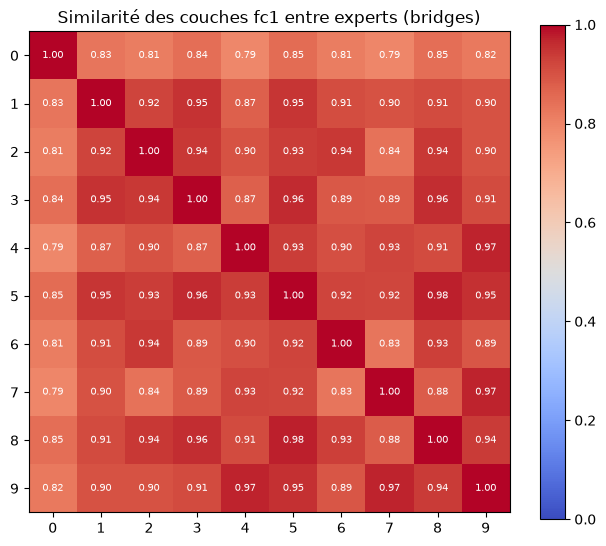

Bridges notables (similarité de couche) :
  4-9 : 0.971 | 8-9 : 0.941 | 1-7 : 0.900 | 8-0 : 0.847


In [6]:
digits_data = {}
for d in range(10):
    mask = torch.as_tensor(test_set.targets) == d
    idx = mask.nonzero().flatten()[:200]
    digits_data[d] = torch.stack([test_set[i][0] for i in idx.tolist()])

# Sur le modèle SharedMoE (nécessaire pour la compression), on doit d'abord
# convertir. On utilise directement SharedMoE pour la suite.
# Matrice de similarité (sur TinyMoE pour l'aperçu)
S = layer_activation_similarity(model, digits_data)
plot_heatmap(S, "Similarité des couches fc1 entre experts (bridges)", list(range(10)))
print("Bridges notables (similarité de couche) :")
print(f"  4-9 : {S[4,9]:.3f} | 8-9 : {S[8,9]:.3f} | 1-7 : {S[1,7]:.3f} | 8-0 : {S[8,0]:.3f}")

## 4. Compression autonome (couches partagées + réentraînement)

In [7]:
# --- Modèle à couches PARTAGÉES (compression autonome) ---
class SharedLayer(nn.Module):
    def __init__(self, d_in, hidden):
        super().__init__()
        self.fc1 = nn.Linear(d_in, hidden); self.act = nn.ReLU()
    def forward(self, x): return self.act(self.fc1(x.flatten(1)))

class SharedExpert(nn.Module):
    def __init__(self, shared, hidden, d_out, classes):
        super().__init__()
        self.shared = shared; self.hidden = hidden; self.d_out = d_out
        self.classes = tuple(classes); self.fc2 = nn.Linear(hidden, d_out)
    def forward(self, x): return self.fc2(self.shared(x))

class SharedMoE(nn.Module):
    def __init__(self, d_in=784, hidden=16, temperature=1.0, seed=0):
        super().__init__()
        torch.manual_seed(seed)
        self.d_in = d_in; self.hidden = hidden; self.temperature = temperature
        self.router = nn.Linear(d_in, 1)
        self.shared_layers = nn.ModuleList(); self.experts = nn.ModuleList()
        self.num_classes = 0; self.forced_expert = None; self.last_routing = None

    def add_expert(self, classes, shared_layer=None, seed=0):
        idx = len(self.experts)
        if shared_layer is None:
            shared_layer = SharedLayer(self.d_in, self.hidden)
            self.shared_layers.append(shared_layer)
        else:
            if not any(sl is shared_layer for sl in self.shared_layers):
                self.shared_layers.append(shared_layer)
        self.experts.append(SharedExpert(shared_layer, self.hidden, len(classes), classes))
        old = self.router; nr = nn.Linear(self.d_in, idx + 1)
        with torch.no_grad():
            nr.weight.data[:idx] = old.weight.data; nr.bias.data[:idx] = old.bias.data
            nr.weight.data[idx] = 0.0; nr.bias.data[idx] = 0.0
        self.router = nr; self.num_classes += len(classes)
        return idx

    def routing_weights(self, x):
        return torch.softmax(self.router(x.flatten(1)) / self.temperature, dim=-1)
    def expert_for_class(self, cls):
        for i, exp in enumerate(self.experts):
            if cls in exp.classes:
                return i
        raise ValueError(f"Aucun expert ne gère la classe {cls}")


    def forward(self, x):
        w = self.routing_weights(x)
        if self.forced_expert is not None:
            w = torch.zeros_like(w); w[:, self.forced_expert] = 1.0
        self.last_routing = w.detach()
        out = torch.zeros(len(x), self.num_classes)
        for i, exp in enumerate(self.experts):
            lg = exp(x); contrib = torch.zeros(len(x), self.num_classes)
            for k, cls in enumerate(exp.classes): contrib[:, cls] = lg[:, k]
            out = out + w[:, i].unsqueeze(1) * contrib
        return out

    def n_params(self):
        n = sum(p.numel() for p in self.router.parameters())
        n += sum(p.numel() for sl in self.shared_layers for p in sl.parameters())
        n += sum(p.numel() for exp in self.experts for p in exp.fc2.parameters())
        return n

    def merge_into_shared(self, a, b):
        ea, eb = self.experts[a], self.experts[b]
        eb.shared = ea.shared
        used = set(id(e.shared) for e in self.experts)
        self.shared_layers = nn.ModuleList([sl for sl in self.shared_layers if id(sl) in used])
        return b

In [8]:
# Entraîner le SharedMoE progressivement (un expert par chiffre), mêmes données
torch.manual_seed(0)
shared_model = SharedMoE(hidden=16)
seen = []
for d in range(10):
    idx = shared_model.add_expert((d,))
    freeze_experts(shared_model, seen)
    data = sets_all[d]
    train_tiny_moe(shared_model, {"train": data['train'], "val": data['val']},
        epochs=8, batch_size=256, lr=1e-3, every_n=100, verbose=False)
    seen.append(idx)
freeze_experts(shared_model, seen)
train_router(shared_model, {"train": sets_all[9]['train'], "val": sets_all[9]['val']},
    epochs=30, batch_size=256, lr=1e-3, every_n=100, verbose=False)
acc_before_compress = evaluate(shared_model, sets_all[9]['test'][0], sets_all[9]['test'][1])
params_before = shared_model.n_params()
print(f"SharedMoE (avant compression) : {params_before} params | acc {acc_before_compress:.4f} | {len(shared_model.shared_layers)} couches")

SharedMoE (avant compression) : 133620 params | acc 0.8391 | 10 couches


In [9]:
# Découverte automatique des paires + compression autonome
pairs = discover_pairs(shared_model, digits_data, n_bridges_min=4)
print(f"{len(pairs)} paires fusionnables découvertes")
shared_model, compression_log = compress_with_retrain(shared_model, pairs, digits_data, sets_all)
params_after = shared_model.n_params()
acc_after_compress = evaluate(shared_model, sets_all[9]['test'][0], sets_all[9]['test'][1])
print(f"\nCompression : {params_before} → {params_after} params ({100*(params_before-params_after)/params_before:.1f}% de réduction)")
print(f"Couches : 10 → {len(shared_model.shared_layers)}")
print(f"Acc : {acc_before_compress:.4f} → {acc_after_compress:.4f}")
print(f"Fusions conservées : {len(compression_log)}/{len(pairs)}")
for c in compression_log:
    print(f"  experts {c['pair'][0]}-{c['pair'][1]} : Δ={c['loss']:+.4f}")

30 paires fusionnables découvertes



Compression : 133620 → 70820 params (47.0% de réduction)
Couches : 10 → 5
Acc : 0.8391 → 0.8230
Fusions conservées : 11/30
  experts 4-6 : Δ=-0.0039
  experts 7-9 : Δ=+0.0004
  experts 3-5 : Δ=+0.0059
  experts 1-2 : Δ=+0.0005
  experts 8-9 : Δ=-0.0165
  experts 1-6 : Δ=-0.0059
  experts 3-8 : Δ=+0.0102
  experts 5-8 : Δ=+0.0079
  experts 4-5 : Δ=-0.0006
  experts 2-6 : Δ=+0.0008
  experts 6-9 : Δ=-0.0149


## 5. Comparaison avec un MLP dense (entraîné sur les 10 chiffres d'un coup)

In [10]:
# --- MLP dense (comparaison : entraîné sur les 10 chiffres d'un coup) ---
def count_params(m): return sum(p.numel() for p in m.parameters())

class MLPDense(nn.Module):
    def __init__(self, d_in=784, hidden=16, d_out=10):
        super().__init__()
        self.fc1 = nn.Linear(d_in, hidden); self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, d_out)
    def forward(self, x): return self.fc2(self.act(self.fc1(x.flatten(1))))

def train_mlp(model, datasets, epochs=25, batch_size=256, lr=1e-3):
    Xtr, ytr = map(torch.as_tensor, datasets['train'])
    Xva, yva = map(torch.as_tensor, datasets['val'])
    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()
    best_acc, best_state = 0.0, None
    for epoch in range(epochs):
        model.train()
        for Xb, yb in loader:
            opt.zero_grad(); loss = lossf(model(Xb), yb); loss.backward(); opt.step()
        model.eval()
        with torch.no_grad(): vcorr = (model(Xva).argmax(1) == yva).sum().item()
        if vcorr/len(Xva) > best_acc:
            best_acc = vcorr/len(Xva); best_state = copy.deepcopy(model.state_dict())
    model.load_state_dict(best_state)
    return best_acc

In [11]:
# MLP dense de référence + balayage
mlp_results = []
for hidden in [16, 32, 64, 89, 128]:
    torch.manual_seed(0)
    m = MLPDense(hidden=hidden, d_out=10)
    train_mlp(m, sets_all[9], epochs=25)
    acc = evaluate(m, sets_all[9]['test'][0], sets_all[9]['test'][1])
    mlp_results.append({'name': f'h={hidden}', 'params': count_params(m), 'acc': acc})
    print(f"  MLP h={hidden:4d} : {count_params(m):6d} params | acc {acc:.4f}")

  MLP h=  16 :  12730 params | acc 0.9502


  MLP h=  32 :  25450 params | acc 0.9681


  MLP h=  64 :  50890 params | acc 0.9740


  MLP h=  89 :  70765 params | acc 0.9775


  MLP h= 128 : 101770 params | acc 0.9779


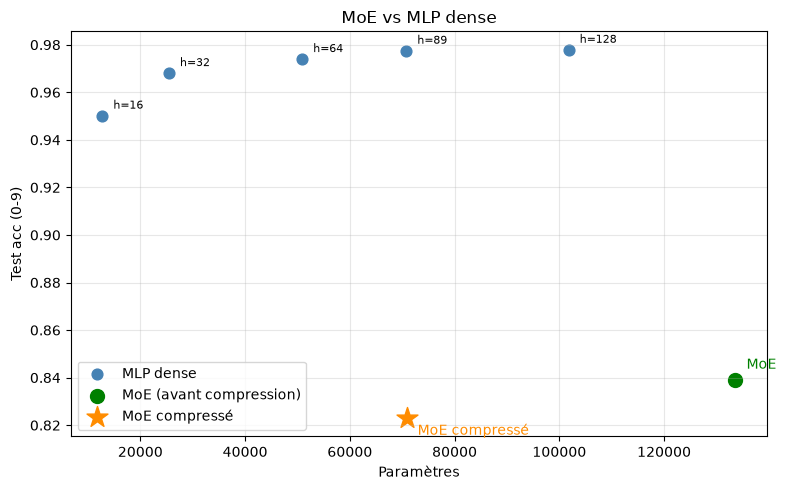

In [12]:
# Courbe params vs acc
fig, ax = plt.subplots(figsize=(8, 5))
xs = [r['params'] for r in mlp_results]; ys = [r['acc'] for r in mlp_results]
ax.scatter(xs, ys, color='steelblue', label='MLP dense', s=60)
for r in mlp_results:
    ax.annotate(r['name'], (r['params'], r['acc']), textcoords='offset points', xytext=(8,5), fontsize=8)
# MoE points
ax.scatter([params_before], [acc_before_compress], color='green', marker='o', s=100, label='MoE (avant compression)')
ax.scatter([params_after], [acc_after_compress], color='darkorange', marker='*', s=250, label='MoE compressé')
ax.annotate('MoE', (params_before, acc_before_compress), textcoords='offset points', xytext=(8,8), color='green')
ax.annotate('MoE compressé', (params_after, acc_after_compress), textcoords='offset points', xytext=(8,-12), color='darkorange')
ax.set_xlabel('Paramètres'); ax.set_ylabel('Test acc (0-9)'); ax.set_title('MoE vs MLP dense')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 6. Synthèse des résultats

In [13]:
print("=" * 60)
print("RÉSUMÉ FINAL")
print("=" * 60)
print(f"MoE 10 experts (non compressé) : {model.n_params()} params | acc {acc_moe_init:.4f}")
print(f"MoE compressé  : {params_before} → {params_after} params (-{100*(params_before-params_after)/params_before:.1f}%) | acc {acc_before_compress:.4f} → {acc_after_compress:.4f}")
print(f"MLP dense h=16 : {mlp_results[0]['params']} params | acc {mlp_results[0]['acc']:.4f}")
print(f"MLP dense h=89 : {mlp_results[3]['params']} params | acc {mlp_results[3]['acc']:.4f}")
print()
print("CONCLUSION : le MLP dense entraîné sur les 10 chiffres d'un coup bat le MoE")
print("compressé à paramètres égaux. Le MoE n'a de sens que pour l'extensibilité")
print("adaptative (ajouter des classes sans réentraîner tout), pas pour la précision")
print("brute. Voir README.md pour l'analyse complète.")

RÉSUMÉ FINAL
MoE 10 experts (non compressé) : 133620 params | acc 0.8421
MoE compressé  : 133620 → 70820 params (-47.0%) | acc 0.8391 → 0.8230
MLP dense h=16 : 12730 params | acc 0.9502
MLP dense h=89 : 70765 params | acc 0.9775

CONCLUSION : le MLP dense entraîné sur les 10 chiffres d'un coup bat le MoE
compressé à paramètres égaux. Le MoE n'a de sens que pour l'extensibilité
adaptative (ajouter des classes sans réentraîner tout), pas pour la précision
brute. Voir README.md pour l'analyse complète.
